### 8 Inteligencia Artificial Explicable (XAI) mediante SHAP

#### 8.1 Objetivo

El objetivo de este notebook es analizar la consistencia explicativa entre el modelo final LightGBM entrenado con datos reales y su equivalente entrenado con datos sintéticos Gaussian Copula V2.1.

La comparación se realizará manteniendo constante la arquitectura predictiva y utilizando el mismo conjunto real de observaciones como base para generar las explicaciones. De esta forma, las diferencias observadas podrán asociarse principalmente a la fuente de entrenamiento utilizada por cada modelo.

El análisis mediante SHAP se abordará desde una perspectiva global y comparativa. En particular, se evaluarán:

- la importancia global de las variables;
- la similitud del ranking de importancia entre ambos modelos;
- el grado de coincidencia entre las variables más relevantes;
- la dirección y magnitud de las contribuciones SHAP;
- y las principales discrepancias explicativas entre los escenarios Real y Synthetic.

El propósito no es únicamente interpretar individualmente cada modelo, sino determinar si la utilidad predictiva observada al utilizar datos sintéticos se encuentra acompañada por patrones explicativos consistentes con los obtenidos mediante datos reales.

Esta etapa responde al objetivo específico relacionado con la evaluación de la consistencia explicativa mediante Inteligencia Artificial Explicable.

#### 8.2 Carga de artefactos

##### 8.2.1 Librerías

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

In [ ]:
#Comprobando version de SHAP
print("SHAP:", shap.__version__)

SHAP: 0.52.0


##### 8.2.2 Carga de modelos finales

In [ ]:
import warnings
warnings.filterwarnings("ignore")
#Leer desde drive
from google.colab import drive
drive.mount('/content/drive')

pd.set_option("display.max_columns", None)

RUTA = "/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM/07_Final_PD_Modeling/"

lgbm_real_final = joblib.load(
    os.path.join(
        RUTA,
        "lgbm_real_final.pkl"
    )
)

lgbm_synthetic_final = joblib.load(
    os.path.join(
        RUTA,
        "lgbm_synthetic_final.pkl"
    )
)

print(type(lgbm_real_final))
print(type(lgbm_synthetic_final))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'sklearn.pipeline.Pipeline'>
<class 'sklearn.pipeline.Pipeline'>


##### 8.2.3 Carga del conjunto común de explicación

In [ ]:
X_test_real = pd.read_parquet(
    os.path.join(
        RUTA,
        "X_test_real.parquet"
    )
)

y_test_real = pd.read_parquet(
    os.path.join(
        RUTA,
        "y_test_real.parquet"
    )
)["TARGET"]

print("X_test_real:", X_test_real.shape)
print("y_test_real:", y_test_real.shape)

print("\nDistribución TARGET:")
print(
    y_test_real
    .value_counts(normalize=True)
    .sort_index()
)

X_test_real: (61502, 39)
y_test_real: (61502,)

Distribución TARGET:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


#### 8.3 Preparación para SHAP

Aquí aparece un detalle importante.

Nuestros objetos finales son pipelines:

ColumnTransformer
      ↓
LightGBM

SHAP no debería aplicarse directamente al pipeline completo, si queremos obtener una comparación clara de las variables que realmente recibe LightGBM.

Debemos extraer:

1. el preprocesador
2. el LightGBM
3. las matrices transformadas
4. los nombres de las variables transformadas.

##### 8.3.1 Extracción de componentes

In [ ]:
preprocessor_real = (
    lgbm_real_final
    .named_steps["preprocessor"]
)

model_real = (
    lgbm_real_final
    .named_steps["model"]
)

preprocessor_synth = (
    lgbm_synthetic_final
    .named_steps["preprocessor"]
)

model_synth = (
    lgbm_synthetic_final
    .named_steps["model"]
)

print(type(preprocessor_real))
print(type(model_real))

print(type(preprocessor_synth))
print(type(model_synth))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>
<class 'lightgbm.sklearn.LGBMClassifier'>
<class 'sklearn.compose._column_transformer.ColumnTransformer'>
<class 'lightgbm.sklearn.LGBMClassifier'>


##### 8.3.2 Transformación del mismo test real

In [ ]:
#Cada modelo debe utilizar su propio preprocesador, porque cada uno fue ajustado con una fuente distinta.
X_test_real_transformed_real = (
    preprocessor_real.transform(
        X_test_real
    )
)

X_test_real_transformed_synth = (
    preprocessor_synth.transform(
        X_test_real
    )
)

print(
    "Test transformado para modelo Real:",
    X_test_real_transformed_real.shape
)

print(
    "Test transformado para modelo Synthetic:",
    X_test_real_transformed_synth.shape
)

Test transformado para modelo Real: (61502, 150)
Test transformado para modelo Synthetic: (61502, 150)


##### 8.3.3 Recuperación de nombres de features

In [ ]:
feature_names_real = (
    preprocessor_real
    .get_feature_names_out()
)

feature_names_synth = (
    preprocessor_synth
    .get_feature_names_out()
)

print(
    "Features modelo Real:",
    len(feature_names_real)
)

print(
    "Features modelo Synthetic:",
    len(feature_names_synth)
)

print("\nPrimeras 20 - Real:")
print(feature_names_real[:20])

print("\nPrimeras 20 - Synthetic:")
print(feature_names_synth[:20])

Features modelo Real: 150
Features modelo Synthetic: 150

Primeras 20 - Real:
['cat__CODE_GENDER_F' 'cat__CODE_GENDER_M'
 'cat__NAME_FAMILY_STATUS_Civil marriage'
 'cat__NAME_FAMILY_STATUS_Married' 'cat__NAME_FAMILY_STATUS_Separated'
 'cat__NAME_FAMILY_STATUS_Single / not married'
 'cat__NAME_FAMILY_STATUS_Unknown' 'cat__NAME_FAMILY_STATUS_Widow'
 'cat__NAME_EDUCATION_TYPE_Academic degree'
 'cat__NAME_EDUCATION_TYPE_Higher education'
 'cat__NAME_EDUCATION_TYPE_Incomplete higher'
 'cat__NAME_EDUCATION_TYPE_Lower secondary'
 'cat__NAME_EDUCATION_TYPE_Secondary / secondary special'
 'cat__NAME_HOUSING_TYPE_Co-op apartment'
 'cat__NAME_HOUSING_TYPE_House / apartment'
 'cat__NAME_HOUSING_TYPE_Municipal apartment'
 'cat__NAME_HOUSING_TYPE_Office apartment'
 'cat__NAME_HOUSING_TYPE_Rented apartment'
 'cat__NAME_HOUSING_TYPE_With parents' 'cat__NAME_INCOME_TYPE_Businessman']

Primeras 20 - Synthetic:
['cat__CODE_GENDER_F' 'cat__CODE_GENDER_M'
 'cat__NAME_FAMILY_STATUS_Civil marriage'
 'cat__NA

In [ ]:
mismos_features = np.array_equal(
    feature_names_real,
    feature_names_synth
)

print(
    "¿Mismo espacio de features?",
    mismos_features
)

¿Mismo espacio de features? True


##### 8.3.4 Convertir a DataFrame transformado

In [ ]:
#Verificar nombres y dimensiones correctos
X_shap_real = pd.DataFrame(
    X_test_real_transformed_real,
    columns=feature_names_real
)

X_shap_synth = pd.DataFrame(
    X_test_real_transformed_synth,
    columns=feature_names_synth
)

print("X_shap_real:", X_shap_real.shape)
print("X_shap_synth:", X_shap_synth.shape)

X_shap_real: (61502, 150)
X_shap_synth: (61502, 150)


#### 8.4 Definición de la muestra SHAP

calcular SHAP inmediatamente sobre las 61,502 observaciones para todos los análisis.

Con TreeSHAP probablemente podría hacerse, pero:

Consume más memoria, genera gráficos innecesariamente pesados y una muestra de varios miles de registros es suficiente para la interpretación global.

Utilizaremos una muestra común de 5,000 observaciones reales, seleccionada de forma reproducible.

##### 8.4.1 Índices comunes

In [ ]:
N_SHAP = 5000
RANDOM_STATE = 42

rng = np.random.default_rng(
    RANDOM_STATE
)

idx_shap = rng.choice(
    len(X_test_real),
    size=N_SHAP,
    replace=False
)

idx_shap = np.sort(idx_shap)

print(
    "Número de observaciones SHAP:",
    len(idx_shap)
)

Número de observaciones SHAP: 5000


##### 8.4.2 Muestras para ambos modelos

In [ ]:
X_shap_sample_real = (
    X_shap_real
    .iloc[idx_shap]
    .reset_index(drop=True)
)

X_shap_sample_synth = (
    X_shap_synth
    .iloc[idx_shap]
    .reset_index(drop=True)
)

y_shap_sample = (
    y_test_real
    .iloc[idx_shap]
    .reset_index(drop=True)
)

print(
    "Sample Real:",
    X_shap_sample_real.shape
)

print(
    "Sample Synthetic:",
    X_shap_sample_synth.shape
)

print("\nTARGET muestra:")
print(
    y_shap_sample
    .value_counts(normalize=True)
    .sort_index()
)

Sample Real: (5000, 150)
Sample Synthetic: (5000, 150)

TARGET muestra:
TARGET
0    0.9192
1    0.0808
Name: proportion, dtype: float64


Por qué esto es importante

Nuestro objetivo no es comparar:

SHAP de personas reales
vs
SHAP de personas sintéticas

porque ahí cambiarían simultáneamente:

modelo;
población explicada.

La comparación principal será:

Mismas personas reales
        ↓
LightGBM Real
vs.
LightGBM Synthetic
        ↓
Comparación SHAP

Mucho más limpio.

#### 8.5 Cálculo de valores SHAP

##### 8.5.1 Creación de los explicadores

In [ ]:
#Como ambos modelos finales son LGBMClassifier, utilizaremos shap.TreeExplainer.
explainer_real = shap.TreeExplainer(
    model_real
)

explainer_synth = shap.TreeExplainer(
    model_synth
)

print(type(explainer_real))
print(type(explainer_synth))

<class 'shap.explainers._tree.TreeExplainer'>
<class 'shap.explainers._tree.TreeExplainer'>


##### 8.5.2 Cálculo de valores SHAP

In [ ]:
shap_values_real = explainer_real(
    X_shap_sample_real
)

shap_values_synth = explainer_synth(
    X_shap_sample_synth
)

In [ ]:
#Comprobamos
print(
    "SHAP Real:",
    shap_values_real.values.shape
)

print(
    "SHAP Synthetic:",
    shap_values_synth.values.shape
)

SHAP Real: (5000, 150)
SHAP Synthetic: (5000, 150)


##### 8.5.3 Verificación de valores base

In [ ]:
#Registro de valores base
print(
    "Base value Real:",
    np.mean(shap_values_real.base_values)
)

print(
    "Base value Synthetic:",
    np.mean(shap_values_synth.base_values)
)

Base value Real: -2.8297828741004243
Base value Synthetic: -2.5135293605101


##### 8.5.4 Verificación de aditividad

Para comprobar que SHAP reconstruye correctamente la salida del modelo, podemos hacer una pequeña prueba con algunas observaciones.

In [ ]:
n_check = 5

for i in range(n_check):

    shap_sum_real = (
        shap_values_real.base_values[i]
        + shap_values_real.values[i].sum()
    )

    model_raw_real = model_real.predict(
        X_shap_sample_real.iloc[[i]],
        raw_score=True
    )[0]

    print(
        f"REAL {i} | SHAP={shap_sum_real:.6f} "
        f"| Model raw={model_raw_real:.6f}"
    )

REAL 0 | SHAP=-4.035090 | Model raw=-4.035090
REAL 1 | SHAP=-1.686264 | Model raw=-1.686264
REAL 2 | SHAP=-2.701297 | Model raw=-2.701297
REAL 3 | SHAP=-4.494715 | Model raw=-4.494715
REAL 4 | SHAP=-4.194903 | Model raw=-4.194903


In [ ]:
for i in range(n_check):

    shap_sum_synth = (
        shap_values_synth.base_values[i]
        + shap_values_synth.values[i].sum()
    )

    model_raw_synth = model_synth.predict(
        X_shap_sample_synth.iloc[[i]],
        raw_score=True
    )[0]

    print(
        f"SYNTH {i} | SHAP={shap_sum_synth:.6f} "
        f"| Model raw={model_raw_synth:.6f}"
    )

SYNTH 0 | SHAP=-2.860991 | Model raw=-2.860991
SYNTH 1 | SHAP=-1.576608 | Model raw=-1.576608
SYNTH 2 | SHAP=-2.113594 | Model raw=-2.113594
SYNTH 3 | SHAP=-3.211957 | Model raw=-3.211957
SYNTH 4 | SHAP=-2.503169 | Model raw=-2.503169


##### 8.5.5 Importancia global SHAP

In [ ]:
#Ahora calculamos la importancia media absoluta de cada feature
importancia_shap_real = pd.DataFrame({
    "feature": feature_names_real,
    "mean_abs_shap_real": np.abs(
        shap_values_real.values
    ).mean(axis=0)
})

importancia_shap_synth = pd.DataFrame({
    "feature": feature_names_synth,
    "mean_abs_shap_synth": np.abs(
        shap_values_synth.values
    ).mean(axis=0)
})

In [ ]:
#Ordenamos
importancia_shap_real = (
    importancia_shap_real
    .sort_values(
        "mean_abs_shap_real",
        ascending=False
    )
    .reset_index(drop=True)
)

importancia_shap_synth = (
    importancia_shap_synth
    .sort_values(
        "mean_abs_shap_synth",
        ascending=False
    )
    .reset_index(drop=True)
)

In [ ]:
#Mostramos top 20
print("=== TOP 20 SHAP - REAL ===")
display(
    importancia_shap_real
    .head(20)
    .round(6)
)

print("\n=== TOP 20 SHAP - SYNTHETIC ===")
display(
    importancia_shap_synth
    .head(20)
    .round(6)
)

=== TOP 20 SHAP - REAL ===


,feature,mean_abs_shap_real
0,remainder__EXT_SOURCE_3,0.362096
1,remainder__EXT_SOURCE_2,0.346647
2,remainder__EXT_SOURCE_1,0.157463
3,remainder__CREDIT_TERM_EST,0.145641
4,cat__CODE_GENDER_F,0.106892
5,remainder__CREDIT_GOODS_RATIO,0.101483
6,remainder__DAYS_EMPLOYED,0.075643
7,cat__NAME_EDUCATION_TYPE_Higher education,0.070826
8,cat__FLAG_OWN_CAR_N,0.063905
9,remainder__AMT_GOODS_PRICE,0.062054



=== TOP 20 SHAP - SYNTHETIC ===


,feature,mean_abs_shap_synth
0,remainder__EXT_SOURCE_2,0.203674
1,remainder__EXT_SOURCE_3,0.192691
2,remainder__CREDIT_GOODS_RATIO,0.092847
3,remainder__EXT_SOURCE_1,0.064041
4,remainder__DAYS_EMPLOYED,0.031062
5,cat__CODE_GENDER_F,0.030342
6,remainder__AMT_ANNUITY,0.024657
7,cat__NAME_INCOME_TYPE_Working,0.024259
8,remainder__HAS_CAR_AGE,0.023260
9,cat__NAME_EDUCATION_TYPE_Secondary / secondary...,0.018685


##### 8.5.6 Primeras gráficas globales

######8.5.6.1 Beeswarm — Real

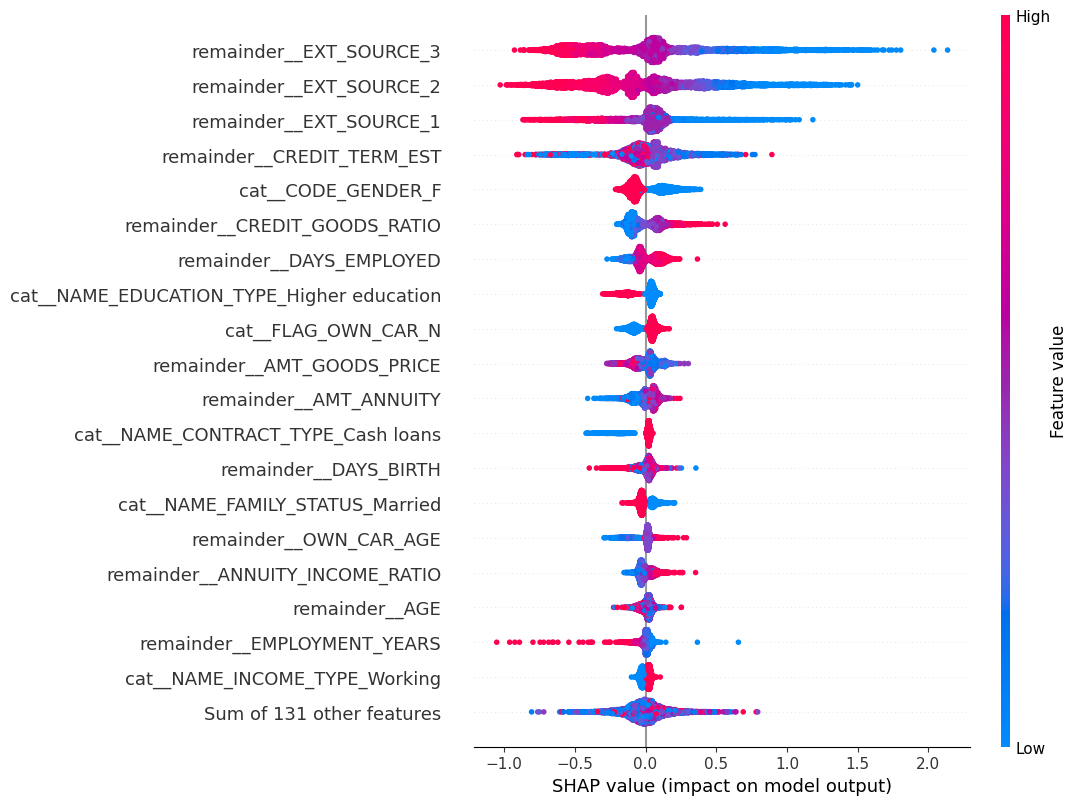

In [ ]:
shap.plots.beeswarm(
    shap_values_real,
    max_display=20
)

###### 8.5.6.2 Beeswarm — Synthetic

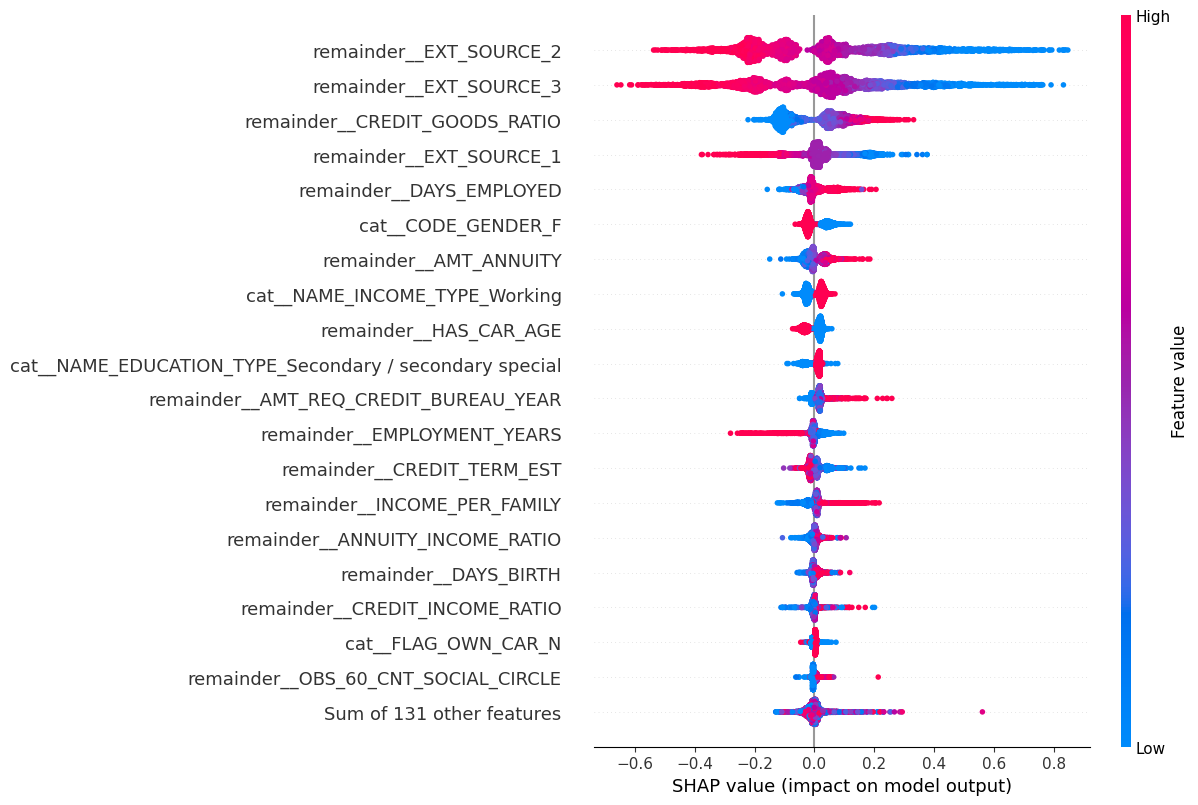

In [ ]:
shap.plots.beeswarm(
    shap_values_synth,
    max_display=20
)

##### 8.5.7 Interpretación inicial de los resultados SHAP

Los resultados obtenidos mediante SHAP muestran que ambos modelos comparten varias de las variables explicativas más relevantes, aunque existen diferencias tanto en el orden de importancia como en la magnitud de las contribuciones.

En ambos escenarios destacan las variables EXT_SOURCE_1, EXT_SOURCE_2 y EXT_SOURCE_3, junto con variables relacionadas con el crédito, la situación laboral y determinadas características sociodemográficas. Esta coincidencia sugiere que una parte de la estructura explicativa aprendida a partir de los datos reales también se encuentra presente en el modelo entrenado con Gaussian Copula V2.1.

Sin embargo, las magnitudes de importancia SHAP son generalmente mayores en el modelo entrenado con datos reales. Por ejemplo, EXT_SOURCE_3 presenta una importancia media absoluta de 0.362096 en el modelo Real frente a 0.192691 en el modelo Synthetic, mientras que EXT_SOURCE_2 alcanza 0.346647 y 0.203674, respectivamente. EXT_SOURCE_1 también presenta una reducción pronunciada, pasando de 0.157463 a 0.064041.

Asimismo, se observan diferencias relevantes en el ranking. CREDIT_TERM_EST ocupa una posición destacada en el modelo Real, con una importancia media absoluta de 0.145641, mientras que en el modelo Synthetic disminuye hasta 0.017000. Por el contrario, CREDIT_GOODS_RATIO conserva una importancia relativamente similar entre ambos modelos.

Las gráficas beeswarm muestran además que la amplitud de las contribuciones SHAP es mayor en el modelo Real, mientras que el modelo Synthetic presenta contribuciones más concentradas alrededor de cero. Este comportamiento es consistente con la compresión de las probabilidades observada durante el análisis predictivo.

En conjunto, los resultados sugieren una consistencia explicativa parcial: ambos modelos comparten varias variables relevantes, pero difieren en la intensidad y jerarquía con la que dichas variables influyen en la estimación del riesgo.

#### 8.6 Consistencia explicativa global

###### 8.6.1 Unificación de importancias

In [ ]:
#Ahora vamos a cuantificar esa similitud.
comparacion_shap = (
    importancia_shap_real
    .merge(
        importancia_shap_synth,
        on="feature",
        how="outer"
    )
    .fillna(0)
)

comparacion_shap["rank_real"] = (
    comparacion_shap["mean_abs_shap_real"]
    .rank(
        ascending=False,
        method="min"
    )
)

comparacion_shap["rank_synth"] = (
    comparacion_shap["mean_abs_shap_synth"]
    .rank(
        ascending=False,
        method="min"
    )
)

comparacion_shap["diff_abs_importance"] = (
    comparacion_shap["mean_abs_shap_real"]
    - comparacion_shap["mean_abs_shap_synth"]
).abs()

comparacion_shap["diff_rank"] = (
    comparacion_shap["rank_real"]
    - comparacion_shap["rank_synth"]
).abs()

comparacion_shap.head()

,feature,mean_abs_shap_real,mean_abs_shap_synth,rank_real,rank_synth,diff_abs_importance,diff_rank
0,cat__CODE_GENDER_F,0.106892,0.030342,5.0,6.0,0.076550,1.0
1,cat__CODE_GENDER_M,0.000071,0.000124,118.0,65.0,0.000053,53.0
2,cat__FLAG_OWN_CAR_N,0.063905,0.005898,9.0,18.0,0.058006,9.0
3,cat__FLAG_OWN_CAR_Y,0.000116,0.000028,110.0,94.0,0.000088,16.0
4,cat__FLAG_OWN_REALTY_N,0.002549,0.000554,48.0,39.0,0.001995,9.0


###### 8.6.2 Correlación de importancia global

In [ ]:
#Calculamos Spearman entre las 150 importancias SHAP.
rho_importancia, p_importancia = spearmanr(
    comparacion_shap["mean_abs_shap_real"],
    comparacion_shap["mean_abs_shap_synth"]
)

print(
    "Spearman importancia SHAP:",
    round(rho_importancia, 6)
)

print(
    "p-value:",
    p_importancia
)

Spearman importancia SHAP: 0.688709
p-value: 2.0336633567379338e-22


In [ ]:
#Tmb entre los rankings
rho_ranking, p_ranking = spearmanr(
    comparacion_shap["rank_real"],
    comparacion_shap["rank_synth"]
)

print(
    "Spearman rankings:",
    round(rho_ranking, 6)
)

print(
    "p-value:",
    p_ranking
)

Spearman rankings: 0.688709
p-value: 2.0336633567379338e-22


##### 8.6.3 Coincidencia Top-N

In [ ]:
#Ahora medimos cuántas variables importantes comparten.
def coincidencia_top_n(df_real, df_synth, n):

    top_real = set(
        df_real
        .head(n)["feature"]
    )

    top_synth = set(
        df_synth
        .head(n)["feature"]
    )

    interseccion = top_real.intersection(
        top_synth
    )

    return {
        "Top_N": n,
        "Coincidencias": len(interseccion),
        "Porcentaje": len(interseccion) / n * 100,
        "Variables_compartidas": sorted(interseccion)
    }

In [ ]:
resultados_top_n = pd.DataFrame([
    coincidencia_top_n(
        importancia_shap_real,
        importancia_shap_synth,
        5
    ),
    coincidencia_top_n(
        importancia_shap_real,
        importancia_shap_synth,
        10
    ),
    coincidencia_top_n(
        importancia_shap_real,
        importancia_shap_synth,
        20
    )
])

display(
    resultados_top_n[
        [
            "Top_N",
            "Coincidencias",
            "Porcentaje"
        ]
    ]
)

,Top_N,Coincidencias,Porcentaje
0,5,3,60.0
1,10,6,60.0
2,20,14,70.0


In [ ]:
#mostramos variables ocmpartidas
for _, fila in resultados_top_n.iterrows():

    print(
        f"\nTOP {fila['Top_N']} "
        f"({fila['Coincidencias']} coincidencias)"
    )

    for feature in fila["Variables_compartidas"]:
        print("-", feature)


TOP 5 (3 coincidencias)
- remainder__EXT_SOURCE_1
- remainder__EXT_SOURCE_2
- remainder__EXT_SOURCE_3

TOP 10 (6 coincidencias)
- cat__CODE_GENDER_F
- remainder__CREDIT_GOODS_RATIO
- remainder__DAYS_EMPLOYED
- remainder__EXT_SOURCE_1
- remainder__EXT_SOURCE_2
- remainder__EXT_SOURCE_3

TOP 20 (14 coincidencias)
- cat__CODE_GENDER_F
- cat__FLAG_OWN_CAR_N
- cat__NAME_INCOME_TYPE_Working
- remainder__AGE
- remainder__AMT_ANNUITY
- remainder__ANNUITY_INCOME_RATIO
- remainder__CREDIT_GOODS_RATIO
- remainder__CREDIT_TERM_EST
- remainder__DAYS_BIRTH
- remainder__DAYS_EMPLOYED
- remainder__EMPLOYMENT_YEARS
- remainder__EXT_SOURCE_1
- remainder__EXT_SOURCE_2
- remainder__EXT_SOURCE_3


##### 8.6.4 Variables con mayores discrepancias

In [ ]:
mayores_discrepancias = (
    comparacion_shap
    .sort_values(
        "diff_abs_importance",
        ascending=False
    )
    .head(20)
)

display(
    mayores_discrepancias[
        [
            "feature",
            "mean_abs_shap_real",
            "mean_abs_shap_synth",
            "rank_real",
            "rank_synth",
            "diff_abs_importance",
            "diff_rank"
        ]
    ].round(6)
)

,feature,mean_abs_shap_real,mean_abs_shap_synth,rank_real,rank_synth,diff_abs_importance,diff_rank
143,remainder__EXT_SOURCE_3,0.362096,0.192691,1.0,2.0,0.169404,1.0
142,remainder__EXT_SOURCE_2,0.346647,0.203674,2.0,1.0,0.142973,1.0
135,remainder__CREDIT_TERM_EST,0.145641,0.017000,4.0,13.0,0.128642,9.0
141,remainder__EXT_SOURCE_1,0.157463,0.064041,3.0,4.0,0.093422,1.0
0,cat__CODE_GENDER_F,0.106892,0.030342,5.0,6.0,0.076550,1.0
9,cat__NAME_EDUCATION_TYPE_Higher education,0.070826,0.000193,8.0,53.0,0.070633,45.0
126,remainder__AMT_GOODS_PRICE,0.062054,0.003243,10.0,24.0,0.058811,14.0
2,cat__FLAG_OWN_CAR_N,0.063905,0.005898,9.0,18.0,0.058006,9.0
137,remainder__DAYS_EMPLOYED,0.075643,0.031062,7.0,5.0,0.044580,2.0
14,cat__NAME_FAMILY_STATUS_Married,0.041000,0.001197,14.0,32.0,0.039803,18.0


##### 8.6.5 Gráfico comparativo de importancias

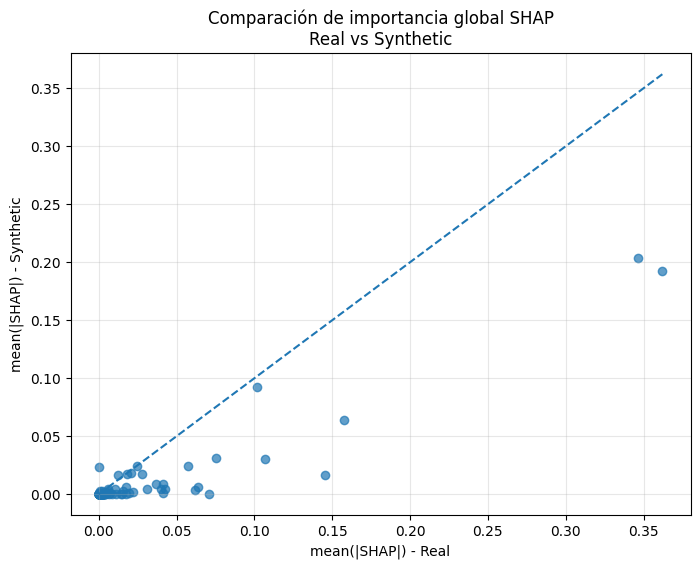

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    comparacion_shap["mean_abs_shap_real"],
    comparacion_shap["mean_abs_shap_synth"],
    alpha=0.7
)

max_val = max(
    comparacion_shap["mean_abs_shap_real"].max(),
    comparacion_shap["mean_abs_shap_synth"].max()
)

plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--"
)

plt.xlabel("mean(|SHAP|) - Real")
plt.ylabel("mean(|SHAP|) - Synthetic")
plt.title(
    "Comparación de importancia global SHAP\nReal vs Synthetic"
)

plt.grid(alpha=0.3)
plt.show()

##### 8.6.6 Interpretación de la consistencia explicativa global

La comparación cuantitativa de las importancias SHAP muestra una asociación positiva entre los patrones explicativos de los modelos entrenados con datos reales y sintéticos. La correlación de Spearman entre las importancias globales alcanzó un valor de 0.688709 (p < 0.001), indicando que las variables que adquieren mayor relevancia en un modelo tienden también a ocupar posiciones relativamente importantes en el otro.

Este resultado no implica equivalencia entre ambos modelos ni debe interpretarse como un porcentaje de consistencia. La correlación refleja únicamente el grado de asociación monotónica existente entre sus patrones de importancia.

El análisis de coincidencia Top-N complementa este resultado. Los modelos comparten 3 de las 5 variables más importantes (60 %), 6 de las 10 primeras (60 %) y 14 de las 20 primeras (70 %). Particularmente, EXT_SOURCE_1, EXT_SOURCE_2 y EXT_SOURCE_3 se encuentran entre las cinco variables más relevantes de ambos modelos, mostrando la conservación de un núcleo común de variables explicativas.

Sin embargo, la similitud en el ranking coexiste con diferencias importantes en la magnitud de las contribuciones. EXT_SOURCE_3 presenta una importancia media absoluta SHAP de 0.362096 en el modelo Real frente a 0.192691 en Synthetic; EXT_SOURCE_2 disminuye de 0.346647 a 0.203674 y EXT_SOURCE_1 de 0.157463 a 0.064041.

También se identificaron discrepancias importantes en determinadas variables. CREDIT_TERM_EST pasa de la posición 4 en el modelo Real a la posición 13 en Synthetic, mientras que su importancia disminuye de 0.145641 a 0.017000. NAME_EDUCATION_TYPE_Higher education pasa de la posición 8 a la 53. En sentido contrario, HAS_CAR_AGE pasa de una contribución prácticamente nula y posición 130 en Real a la posición 9 en Synthetic.

El gráfico comparativo confirma que varias de las variables más importantes se sitúan por debajo de la diagonal de igualdad, mostrando que el modelo Synthetic tiende a asignar contribuciones de menor magnitud a algunas de las variables dominantes del modelo Real.

En conjunto, los resultados proporcionan evidencia de una consistencia explicativa global parcial: existe una conservación relevante del núcleo de variables predictivas y una asociación positiva entre sus rankings, pero no una reproducción completa de la jerarquía ni de la magnitud de sus contribuciones.

#### 8.7 Consistencia en la dirección de los efectos

Hasta ahora usamos:

mean(|SHAP|)

y al aplicar valor absoluto perdemos el signo.

Sabemos que ambos modelos consideran importante EXT_SOURCE_2, por ejemplo, pero aún debemos responder:

¿Un valor alto de EXT_SOURCE_2 empuja la predicción de PD en la misma dirección en ambos modelos?

Tus beeswarm visualmente sugieren que sí para varias variables. Ahora lo cuantificaremos.

##### 8.7.1 Correlación feature–SHAP

Para cada una de las 150 features calcularemos la correlación de Spearman entre:

valor de la feature ↔ valor SHAP

por separado en Real y Synthetic.

In [ ]:
from scipy.stats import spearmanr

resultados_direccion = []

for feature in feature_names_real:

    x_real = X_shap_sample_real[feature]
    s_real = shap_values_real[:, feature].values

    x_synth = X_shap_sample_synth[feature]
    s_synth = shap_values_synth[:, feature].values

    rho_real, _ = spearmanr(
        x_real,
        s_real
    )

    rho_synth, _ = spearmanr(
        x_synth,
        s_synth
    )

    resultados_direccion.append({
        "feature": feature,
        "rho_feature_shap_real": rho_real,
        "rho_feature_shap_synth": rho_synth
    })

direccion_shap = pd.DataFrame(
    resultados_direccion
)

direccion_shap.head()

,feature,rho_feature_shap_real,rho_feature_shap_synth
0,cat__CODE_GENDER_F,-0.825736,-0.824472
1,cat__CODE_GENDER_M,-0.441158,0.788357
2,cat__NAME_FAMILY_STATUS_Civil marriage,0.478150,-0.461417
3,cat__NAME_FAMILY_STATUS_Married,-0.827313,0.813413
4,cat__NAME_FAMILY_STATUS_Separated,0.434309,-0.342217


In [ ]:
#Es posible que algunas variables constantes o casi constantes generen NaN. Los trataremos explícitamente:
print(
    "NaN Real:",
    direccion_shap[
        "rho_feature_shap_real"
    ].isna().sum()
)

print(
    "NaN Synthetic:",
    direccion_shap[
        "rho_feature_shap_synth"
    ].isna().sum()
)

NaN Real: 21
NaN Synthetic: 50


##### 8.7.2 Dirección de las variables Top-20 Real

In [ ]:
#Lo uniremos con la simportancias
direccion_top20 = (
    importancia_shap_real
    .head(20)[
        ["feature", "mean_abs_shap_real"]
    ]
    .merge(
        importancia_shap_synth[
            ["feature", "mean_abs_shap_synth"]
        ],
        on="feature",
        how="left"
    )
    .merge(
        direccion_shap,
        on="feature",
        how="left"
    )
)

In [ ]:
#Añadimos una clasificación sencilla del signo:
def obtener_direccion(rho):

    if pd.isna(rho):
        return "No evaluable"

    if rho > 0:
        return "Positiva"

    if rho < 0:
        return "Negativa"

    return "Neutra"


direccion_top20["direccion_real"] = (
    direccion_top20[
        "rho_feature_shap_real"
    ].apply(obtener_direccion)
)

direccion_top20["direccion_synth"] = (
    direccion_top20[
        "rho_feature_shap_synth"
    ].apply(obtener_direccion)
)

direccion_top20["mismo_signo"] = (
    direccion_top20["direccion_real"]
    ==
    direccion_top20["direccion_synth"]
)

In [ ]:
#Mostramos
display(
    direccion_top20[
        [
            "feature",
            "mean_abs_shap_real",
            "mean_abs_shap_synth",
            "rho_feature_shap_real",
            "rho_feature_shap_synth",
            "direccion_real",
            "direccion_synth",
            "mismo_signo"
        ]
    ].round(6)
)

,feature,mean_abs_shap_real,mean_abs_shap_synth,rho_feature_shap_real,rho_feature_shap_synth,direccion_real,direccion_synth,mismo_signo
0,remainder__EXT_SOURCE_3,0.362096,0.192691,-0.956694,-0.988208,Negativa,Negativa,True
1,remainder__EXT_SOURCE_2,0.346647,0.203674,-0.990624,-0.985033,Negativa,Negativa,True
2,remainder__EXT_SOURCE_1,0.157463,0.064041,-0.693879,-0.874341,Negativa,Negativa,True
3,remainder__CREDIT_TERM_EST,0.145641,0.017000,-0.149060,-0.870398,Negativa,Negativa,True
4,cat__CODE_GENDER_F,0.106892,0.030342,-0.825736,-0.824472,Negativa,Negativa,True
5,remainder__CREDIT_GOODS_RATIO,0.101483,0.092847,0.901320,0.957061,Positiva,Positiva,True
6,remainder__DAYS_EMPLOYED,0.075643,0.031062,0.928363,0.921135,Positiva,Positiva,True
7,cat__NAME_EDUCATION_TYPE_Higher education,0.070826,0.000193,-0.750000,-0.262924,Negativa,Negativa,True
8,cat__FLAG_OWN_CAR_N,0.063905,0.005898,0.823471,0.739960,Positiva,Positiva,True
9,remainder__AMT_GOODS_PRICE,0.062054,0.003243,-0.548266,-0.413359,Negativa,Negativa,True


##### 8.7.3 Porcentaje de conservación direccional

In [ ]:
variables_evaluables = direccion_top20[
    (direccion_top20["direccion_real"] != "No evaluable") &
    (direccion_top20["direccion_synth"] != "No evaluable")
]

n_evaluables = len(
    variables_evaluables
)

n_mismo_signo = (
    variables_evaluables["mismo_signo"]
    .sum()
)

porcentaje_mismo_signo = (
    n_mismo_signo /
    n_evaluables *
    100
)

print(
    "Variables evaluables:",
    n_evaluables
)

print(
    "Mismo signo:",
    n_mismo_signo
)

print(
    "Conservación direccional:",
    round(porcentaje_mismo_signo, 2),
    "%"
)

Variables evaluables: 20
Mismo signo: 19
Conservación direccional: 95.0 %


#####8.7.4 Consistencia direccional de variables con efecto relevante

Definamos de forma descriptiva una relación feature-SHAP como relevante cuando:

|rho| >= 0.20

No lo presentamos como una ley estadística universal; es un criterio operacional para evitar interpretar signos de relaciones prácticamente nulas.

In [ ]:
UMBRAL_RHO = 0.20

direccion_top20["efecto_relevante_real"] = (
    direccion_top20[
        "rho_feature_shap_real"
    ].abs() >= UMBRAL_RHO
)

direccion_top20["efecto_relevante_synth"] = (
    direccion_top20[
        "rho_feature_shap_synth"
    ].abs() >= UMBRAL_RHO
)

direccion_top20["relevante_ambos"] = (
    direccion_top20["efecto_relevante_real"]
    &
    direccion_top20["efecto_relevante_synth"]
)

direccion_relevante = direccion_top20[
    direccion_top20["relevante_ambos"]
].copy()

display(
    direccion_relevante[
        [
            "feature",
            "rho_feature_shap_real",
            "rho_feature_shap_synth",
            "direccion_real",
            "direccion_synth",
            "mismo_signo"
        ]
    ].round(6)
)

,feature,rho_feature_shap_real,rho_feature_shap_synth,direccion_real,direccion_synth,mismo_signo
0,remainder__EXT_SOURCE_3,-0.956694,-0.988208,Negativa,Negativa,True
1,remainder__EXT_SOURCE_2,-0.990624,-0.985033,Negativa,Negativa,True
2,remainder__EXT_SOURCE_1,-0.693879,-0.874341,Negativa,Negativa,True
4,cat__CODE_GENDER_F,-0.825736,-0.824472,Negativa,Negativa,True
5,remainder__CREDIT_GOODS_RATIO,0.901320,0.957061,Positiva,Positiva,True
6,remainder__DAYS_EMPLOYED,0.928363,0.921135,Positiva,Positiva,True
7,cat__NAME_EDUCATION_TYPE_Higher education,-0.750000,-0.262924,Negativa,Negativa,True
8,cat__FLAG_OWN_CAR_N,0.823471,0.739960,Positiva,Positiva,True
9,remainder__AMT_GOODS_PRICE,-0.548266,-0.413359,Negativa,Negativa,True
10,remainder__AMT_ANNUITY,0.801831,0.926004,Positiva,Positiva,True


In [ ]:
#Resumen
if len(direccion_relevante) > 0:

    porcentaje_relevante = (
        direccion_relevante[
            "mismo_signo"
        ].mean() * 100
    )

    print(
        "Variables con relación relevante en ambos:",
        len(direccion_relevante)
    )

    print(
        "Conservación del signo:",
        round(porcentaje_relevante, 2),
        "%"
    )

Variables con relación relevante en ambos: 16
Conservación del signo: 93.75 %


##### 8.7.5 Interpretación de la consistencia direccional

Resultados

| Evaluación                           |   Resultado |          |    |
| ------------------------------------ | ----------: | -------- | -- |
| Top-20 evaluables                    |          20 |          |    |
| Mismo signo                          |   **19/20** |          |    |
| Conservación direccional             |  **95.0 %** |          |    |
| Efecto relevante en ambos (`         |           ρ | ≥ 0.20`) | 16 |
| Mismo signo entre efectos relevantes |   **15/16** |          |    |
| Conservación direccional relevante   | **93.75 %** |          |    |


VAriables especialmente consistentes:


| Variable     |  ρ Real | ρ Synthetic |
| ------------ | ------: | ----------: |
| EXT_SOURCE_3 | -0.9567 |     -0.9882 |
| EXT_SOURCE_2 | -0.9906 |     -0.9850 |
| EXT_SOURCE_1 | -0.6939 |     -0.8743 |


También tenemos:

CREDIT_GOODS_RATIO: +0.9013 / +0.9571

DAYS_EMPLOYED: +0.9284 / +0.9211

AMT_ANNUITY: +0.8018 / +0.9260

ANNUITY_INCOME_RATIO: +0.8155 / +0.8408

EMPLOYMENT_YEARS: -0.8834 / -0.8581

Son coincidencias direccionales muy marcadas.

**La excepción: Married**

La única inversión entre las 16 relaciones relevantes es:

NAME_FAMILY_STATUS_Married

Real: ρ = -0.8273
Synthetic: ρ = +0.8134

Esto sí es una discrepancia explicativa real.

Pero hay un matiz importante: su importancia SHAP cae de:

Real: 0.041000, rango 14
Synthetic: 0.001197, rango 32.

Por tanto, aunque existe inversión del signo, en el modelo Synthetic esta categoría tiene una contribución global mucho menor.

No debemos esconder esa discrepancia; al contrario, es evidencia de que los datos sintéticos no reproducen todas las relaciones explicativas.

**Conslusiones**

La comparación de la relación entre los valores de las variables y sus contribuciones SHAP muestra un elevado grado de consistencia direccional entre los modelos Real y Synthetic.

Entre las veinte variables más importantes del modelo Real, 19 presentaron el mismo signo de correlación feature-SHAP en ambos modelos, equivalente a una coincidencia direccional del 95 %. Debido a que relaciones de magnitud prácticamente nula podrían producir cambios de signo sin relevancia explicativa, se realizó adicionalmente un análisis restringido a aquellas variables cuya correlación absoluta fue igual o superior a 0.20 en ambos modelos. Bajo este criterio operacional, 16 variables fueron evaluables y 15 conservaron el mismo signo, obteniéndose una coincidencia direccional del 93.75 %.

Las variables EXT_SOURCE_1, EXT_SOURCE_2 y EXT_SOURCE_3 presentan relaciones negativas en ambos modelos. Particularmente, EXT_SOURCE_2 alcanza correlaciones de -0.990624 en Real y -0.985033 en Synthetic, mientras que EXT_SOURCE_3 alcanza -0.956694 y -0.988208, respectivamente. Esto indica que valores mayores de estas variables se encuentran asociados con contribuciones SHAP que reducen la salida del modelo hacia la clase de default en ambos escenarios.

También se observa una elevada consistencia en variables como CREDIT_GOODS_RATIO, DAYS_EMPLOYED, AMT_ANNUITY y ANNUITY_INCOME_RATIO, que presentan relaciones positivas en ambos modelos, así como EMPLOYMENT_YEARS, que mantiene una relación negativa.

La principal discrepancia direccional entre las variables relevantes corresponde a la categoría NAME_FAMILY_STATUS_Married, cuya correlación cambia de -0.827313 en el modelo Real a 0.813413 en Synthetic. Sin embargo, su importancia global disminuye considerablemente en el modelo Synthetic, pasando de una importancia SHAP media absoluta de 0.041000 y posición 14 a 0.001197 y posición 32. Este resultado constituye una discrepancia explicativa concreta y evidencia que el conjunto sintético no reproduce de forma completa todas las relaciones aprendidas a partir de los datos reales.

Para las variables categóricas transformadas mediante one-hot encoding, el signo de la correlación debe interpretarse como la asociación entre la presencia de una categoría y su contribución SHAP, y no como una relación continua entre magnitud de la variable y riesgo.

En conjunto, los resultados muestran que la consistencia explicativa no es uniforme en todas sus dimensiones. Aunque existen diferencias relevantes en la magnitud y el ranking de las importancias globales, la dirección de los efectos de las principales variables se conserva en gran medida entre los modelos entrenados con datos reales y sintéticos.

#### 8.8 Comparación de contribuciones SHAP por observación

Ahora podemos ir un nivel más profundo.

Hasta ahora sabemos:

“EXT_SOURCE_2 tiene la misma dirección general en ambos modelos”.

Pero todavía no sabemos si para una misma persona, ambos modelos le asignan contribuciones similares.

Como usamos exactamente las mismas 5,000 observaciones reales, podemos medirlo.

##### 8.8.1 Correlación SHAP Real vs Synthetic por feature

Para cada feature calcularemos:

$$ \rho(SHAP_{Real}, SHAP_{Synthetic}) $$

sobre las mismas 5,000 observaciones.

In [ ]:
resultados_contribuciones = []

for feature in feature_names_real:

    shap_real_feature = (
        shap_values_real[:, feature]
        .values
    )

    shap_synth_feature = (
        shap_values_synth[:, feature]
        .values
    )

    rho, p_value = spearmanr(
        shap_real_feature,
        shap_synth_feature
    )

    resultados_contribuciones.append({
        "feature": feature,
        "rho_shap_real_synth": rho,
        "p_value": p_value
    })

consistencia_contribuciones = pd.DataFrame(
    resultados_contribuciones
)

print(
    "NaN:",
    consistencia_contribuciones[
        "rho_shap_real_synth"
    ].isna().sum()
)

NaN: 54


##### 8.8.2 Unir importancia y consistencia individual

In [ ]:
consistencia_contribuciones = (
    consistencia_contribuciones
    .merge(
        comparacion_shap[
            [
                "feature",
                "mean_abs_shap_real",
                "mean_abs_shap_synth",
                "rank_real",
                "rank_synth"
            ]
        ],
        on="feature",
        how="left"
    )
)

In [ ]:
# Mostramos las Top-20 del modelo Real:
consistencia_top20 = (
    consistencia_contribuciones
    .sort_values(
        "rank_real"
    )
    .head(20)
)

display(
    consistencia_top20[
        [
            "feature",
            "rank_real",
            "rank_synth",
            "mean_abs_shap_real",
            "mean_abs_shap_synth",
            "rho_shap_real_synth"
        ]
    ].round(6)
)

,feature,rank_real,rank_synth,mean_abs_shap_real,mean_abs_shap_synth,rho_shap_real_synth
134,remainder__EXT_SOURCE_3,1.0,2.0,0.362096,0.192691,0.940839
133,remainder__EXT_SOURCE_2,2.0,1.0,0.346647,0.203674,0.975219
132,remainder__EXT_SOURCE_1,3.0,4.0,0.157463,0.064041,0.599092
149,remainder__CREDIT_TERM_EST,4.0,13.0,0.145641,0.017000,0.137548
0,cat__CODE_GENDER_F,5.0,6.0,0.106892,0.030342,0.653800
146,remainder__CREDIT_GOODS_RATIO,6.0,3.0,0.101483,0.092847,0.867783
138,remainder__DAYS_EMPLOYED,7.0,5.0,0.075643,0.031062,0.875830
9,cat__NAME_EDUCATION_TYPE_Higher education,8.0,53.0,0.070826,0.000193,0.163954
103,cat__FLAG_OWN_CAR_N,9.0,18.0,0.063905,0.005898,0.584514
126,remainder__AMT_GOODS_PRICE,10.0,24.0,0.062054,0.003243,0.284196


Aquí un ρ alto significa algo mucho más exigente:

para las mismas personas, cuando una variable produce una contribución relativamente alta/baja en el modelo Real, tiende a hacerlo también en Synthetic.

##### 8.8.3 Resumen de correlaciones individuales

No conviene promediar ciegamente las 150 features, porque muchas tienen importancia prácticamente nula.

Concentrémonos primero en las Top-20 Real.

In [ ]:
rho_top20 = (
    consistencia_top20[
        "rho_shap_real_synth"
    ]
    .dropna()
)

print(
    "Correlación media Top-20:",
    round(rho_top20.mean(), 6)
)

print(
    "Correlación mediana Top-20:",
    round(rho_top20.median(), 6)
)

print(
    "Mínima Top-20:",
    round(rho_top20.min(), 6)
)

print(
    "Máxima Top-20:",
    round(rho_top20.max(), 6)
)

Correlación media Top-20: 0.467373
Correlación mediana Top-20: 0.591803
Mínima Top-20: -0.668212
Máxima Top-20: 0.975219


In [ ]:
# Distribucion
resumen_consistencia_individual = pd.DataFrame({
    "Criterio": [
        "rho >= 0.80",
        "rho >= 0.60",
        "rho >= 0.40",
        "rho < 0.40"
    ],
    "Numero_variables": [
        (rho_top20 >= 0.80).sum(),
        (rho_top20 >= 0.60).sum(),
        (rho_top20 >= 0.40).sum(),
        (rho_top20 < 0.40).sum()
    ]
})

display(
    resumen_consistencia_individual
)

,Criterio,Numero_variables
0,rho >= 0.80,4
1,rho >= 0.60,9
2,rho >= 0.40,11
3,rho < 0.40,9


Ojo: las categorías son acumulativas en las tres primeras filas. Lo utilizamos solo como resumen descriptivo, no como porcentajes excluyentes.

##### 8.8.4 Scatter SHAP de una variable principal

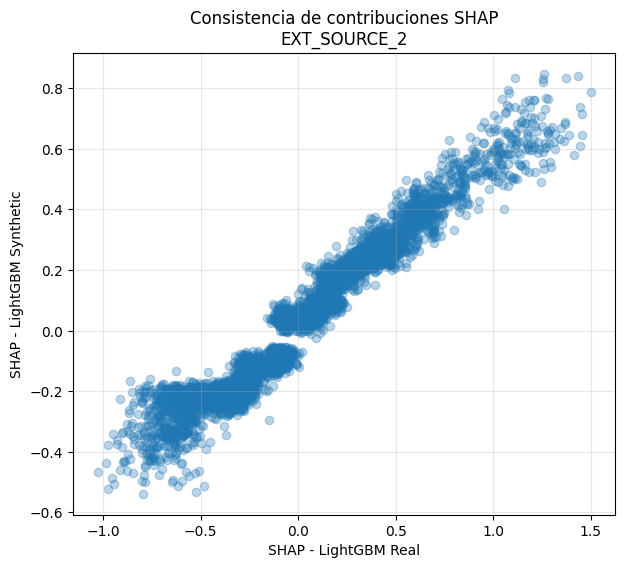

In [ ]:
#Finalmente hagamos algo visual con EXT_SOURCE_2, nuestra variable principal compartida.
feature_comparar = "remainder__EXT_SOURCE_2"

idx_feature = list(
    feature_names_real
).index(
    feature_comparar
)

plt.figure(figsize=(7, 6))

plt.scatter(
    shap_values_real.values[:, idx_feature],
    shap_values_synth.values[:, idx_feature],
    alpha=0.3
)

plt.xlabel(
    "SHAP - LightGBM Real"
)

plt.ylabel(
    "SHAP - LightGBM Synthetic"
)

plt.title(
    "Consistencia de contribuciones SHAP\n"
    "EXT_SOURCE_2"
)

plt.grid(alpha=0.3)
plt.show()

##### 8.8.5 Interpretación de la consistencia por observación

Variables con consistencia muy alta

Destacan especialmente:

EXT_SOURCE_2: 0.975219
EXT_SOURCE_3: 0.940839
DAYS_EMPLOYED: 0.875830
CREDIT_GOODS_RATIO: 0.867783

Esto significa que, para las mismas 5,000 observaciones reales, cuando estas variables producen una contribución SHAP alta o baja en el modelo Real, tienden a hacerlo también en el Synthetic.

Tu scatter de EXT_SOURCE_2 lo muestra muy bien: la nube sigue una relación claramente creciente y bastante compacta.


Consistencia intermedia

También son razonablemente consistentes:

NAME_INCOME_TYPE_Working: 0.793115
EMPLOYMENT_YEARS: 0.785263
AMT_ANNUITY: 0.740945
ANNUITY_INCOME_RATIO: 0.705670
CODE_GENDER_F: 0.653800
EXT_SOURCE_1: 0.599092
Variables con baja consistencia

Aquí aparecen las discrepancias más importantes:

CREDIT_TERM_EST: 0.137548
NAME_EDUCATION_TYPE_Higher education: 0.163954
DAYS_BIRTH: 0.017956
AMT_CREDIT: 0.000345

Y la discrepancia más clara:

NAME_FAMILY_STATUS_Married: -0.668212

Esa correlación negativa significa que, para las mismas observaciones, la contribución de esa categoría tiende a moverse en sentido opuesto entre ambos modelos.

Eso encaja con lo que ya vimos en 8.7: era precisamente la variable que invertía signo en la relación feature-SHAP.


**Conclusioens**

El análisis de las contribuciones SHAP sobre las mismas 5 000 observaciones reales muestra que la consistencia explicativa a nivel individual es heterogénea entre variables.

Considerando las veinte variables más importantes del modelo Real, la correlación media entre las contribuciones SHAP de ambos modelos fue de 0.467373 y la mediana de 0.591803. Estos valores indican una consistencia moderada a nivel individual, aunque con diferencias sustanciales entre variables.

Algunas variables presentan una elevada concordancia entre modelos. EXT_SOURCE_2 alcanzó una correlación de 0.975219 y EXT_SOURCE_3 de 0.940839, mostrando que sus contribuciones relativas sobre las mismas observaciones se conservan de forma muy consistente. También destacan DAYS_EMPLOYED (0.875830) y CREDIT_GOODS_RATIO (0.867783).

Otras variables presentan niveles intermedios de consistencia, como NAME_INCOME_TYPE_Working (0.793115), EMPLOYMENT_YEARS (0.785263), AMT_ANNUITY (0.740945), ANNUITY_INCOME_RATIO (0.705670) y CODE_GENDER_F (0.653800).

En contraste, algunas variables muestran una concordancia reducida, entre ellas CREDIT_TERM_EST (0.137548), NAME_EDUCATION_TYPE_Higher education (0.163954), DAYS_BIRTH (0.017956) y AMT_CREDIT (0.000345).

La discrepancia más pronunciada corresponde a NAME_FAMILY_STATUS_Married, cuya correlación entre contribuciones SHAP fue de -0.668212. Este resultado indica que las contribuciones individuales asociadas a dicha categoría presentan un comportamiento opuesto entre los modelos, coherente con la inversión de dirección identificada previamente.

En conjunto, los resultados muestran que la consistencia explicativa entre modelos no se limita a una coincidencia global de variables relevantes. Algunas variables conservan de forma muy elevada sus patrones de contribución sobre las mismas observaciones, mientras que otras presentan diferencias sustanciales. Por tanto, la información sintética preserva parcialmente la estructura explicativa individual, pero no la reproduce de manera uniforme.

##### 8.8.6 Interpretación del scatter de EXT_SOURCE_2

La comparación de las contribuciones SHAP de EXT_SOURCE_2 muestra una relación positiva muy marcada entre los modelos Real y Synthetic.

La correlación de Spearman entre las contribuciones de ambos modelos alcanza 0.975219, indicando que las observaciones a las que el modelo Real asigna una contribución más negativa o más positiva debido a EXT_SOURCE_2 tienden a recibir contribuciones similares en términos relativos por parte del modelo Synthetic.

Aunque la magnitud de las contribuciones es generalmente menor en el modelo Synthetic, la estructura relativa de los efectos se conserva de forma muy elevada. Este resultado muestra que la consistencia explicativa puede mantenerse incluso cuando la intensidad absoluta de las contribuciones difiere entre modelos.

#### 8.9 Análisis local de casos representativos

##### 8.9.1 Objetivo

Además de la evaluación global de consistencia explicativa, se realiza un análisis local sobre observaciones individuales del conjunto real de prueba.

El objetivo es analizar si los modelos entrenados con datos reales y sintéticos proporcionan explicaciones coherentes cuando evalúan exactamente al mismo solicitante. Para cada caso se compararán la probabilidad estimada de default y las principales contribuciones SHAP que incrementan o reducen la salida del modelo.

Los casos no se seleccionan manualmente en función de sus explicaciones SHAP. Se utilizan criterios reproducibles basados en el TARGET observado y en el grado de concordancia o discrepancia entre las probabilidades estimadas por ambos modelos.

Este análisis tiene carácter ilustrativo y complementario. Los casos individuales no se utilizan para establecer conclusiones generales, las cuales se sustentan en los análisis globales realizados sobre la muestra de 5 000 observaciones.

##### 8.9.2 Probabilidades de ambos modelos sobre los mismos casos

In [ ]:
#Como ya tenemos las 5,000 observaciones, calculemos las probabilidades.
prob_real_shap = model_real.predict_proba(
    X_shap_sample_real
)[:, 1]

prob_synth_shap = model_synth.predict_proba(
    X_shap_sample_synth
)[:, 1]

comparacion_local = pd.DataFrame({
    "idx_sample": np.arange(len(idx_shap)),
    "idx_test": idx_shap,
    "TARGET": y_shap_sample.values,
    "PD_Real": prob_real_shap,
    "PD_Synthetic": prob_synth_shap
})

comparacion_local["Diferencia_PD"] = (
    comparacion_local["PD_Synthetic"]
    - comparacion_local["PD_Real"]
)

comparacion_local["Diferencia_Absoluta_PD"] = (
    comparacion_local["Diferencia_PD"].abs()
)

display(
    comparacion_local.head().round(6)
)

,idx_sample,idx_test,TARGET,PD_Real,PD_Synthetic,Diferencia_PD,Diferencia_Absoluta_PD
0,0,30,0,0.017377,0.054116,0.036739,0.036739
1,1,32,0,0.156268,0.171276,0.015009,0.015009
2,2,63,0,0.062897,0.107783,0.044886,0.044886
3,3,73,0,0.011045,0.038718,0.027674,0.027674
4,4,74,0,0.014848,0.075636,0.060788,0.060788


Aquí utilizamos “PD estimada” como probabilidad producida por el modelo. Posteriormente tendremos cuidado porque nuestros resultados de calibración indican que no debemos interpretar estas probabilidades como PD perfectamente calibradas.

##### 8.9.3 Relación entre probabilidades Real y Synthetic

In [ ]:
#Antes de seleccionar clientes, vale la pena medir la concordancia global de las probabilidades sobre esas mismas 5,000 observaciones.
rho_pd, p_pd = spearmanr(
    comparacion_local["PD_Real"],
    comparacion_local["PD_Synthetic"]
)

mae_pd = np.mean(
    np.abs(
        comparacion_local["PD_Real"]
        - comparacion_local["PD_Synthetic"]
    )
)

print(
    "Spearman PD Real vs Synthetic:",
    round(rho_pd, 6)
)

print(
    "p-value:",
    p_pd
)

print(
    "MAE probabilidades:",
    round(mae_pd, 6)
)

print(
    "\nProbabilidad media Real:",
    round(comparacion_local["PD_Real"].mean(), 6)
)

print(
    "Probabilidad media Synthetic:",
    round(comparacion_local["PD_Synthetic"].mean(), 6)
)

Spearman PD Real vs Synthetic: 0.848161
p-value: 0.0
MAE probabilidades: 0.039968

Probabilidad media Real: 0.080358
Probabilidad media Synthetic: 0.087867


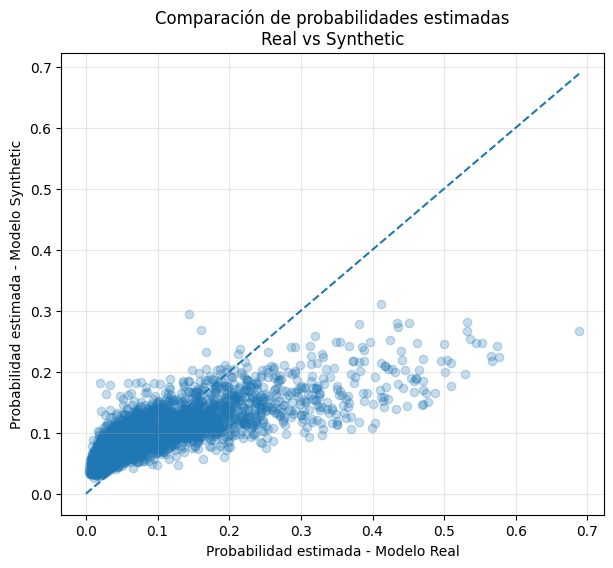

In [ ]:
plt.figure(figsize=(7, 6))

plt.scatter(
    comparacion_local["PD_Real"],
    comparacion_local["PD_Synthetic"],
    alpha=0.25
)

max_prob = max(
    comparacion_local["PD_Real"].max(),
    comparacion_local["PD_Synthetic"].max()
)

plt.plot(
    [0, max_prob],
    [0, max_prob],
    linestyle="--"
)

plt.xlabel("Probabilidad estimada - Modelo Real")
plt.ylabel("Probabilidad estimada - Modelo Synthetic")

plt.title(
    "Comparación de probabilidades estimadas\n"
    "Real vs Synthetic"
)

plt.grid(alpha=0.3)
plt.show()

##### 8.9.4 Selección reproducible de casos

No utilizaremos un threshold de 0.50 para seleccionarlos porque ya vimos que, especialmente en Synthetic, 0.50 no es un umbral operativo adecuado.

Vamos a seleccionar:

1. TARGET=0, alta concordancia de probabilidades.
2. TARGET=1, alta concordancia de probabilidades.
3. TARGET=0, gran discrepancia de probabilidades.
4. TARGET=1, gran discrepancia de probabilidades.

Eso nos permite estudiar tanto coherencia como limitaciones.

Para evitar escoger simplemente probabilidades casi cero como “gran concordancia”, dentro de cada TARGET tomaremos como caso concordante aquel con menor diferencia entre modelos entre observaciones cuya PD Real esté por encima de la mediana de su grupo.

In [ ]:
def seleccionar_caso_concordante(df, target):

    subset = df[
        df["TARGET"] == target
    ].copy()

    mediana_pd = subset[
        "PD_Real"
    ].median()

    subset = subset[
        subset["PD_Real"] >= mediana_pd
    ]

    return (
        subset
        .sort_values(
            "Diferencia_Absoluta_PD"
        )
        .iloc[0]
    )


def seleccionar_caso_discrepante(df, target):

    subset = df[
        df["TARGET"] == target
    ].copy()

    return (
        subset
        .sort_values(
            "Diferencia_Absoluta_PD",
            ascending=False
        )
        .iloc[0]
    )

In [ ]:
caso_1 = seleccionar_caso_concordante(
    comparacion_local,
    target=0
)

caso_2 = seleccionar_caso_concordante(
    comparacion_local,
    target=1
)

caso_3 = seleccionar_caso_discrepante(
    comparacion_local,
    target=0
)

caso_4 = seleccionar_caso_discrepante(
    comparacion_local,
    target=1
)

casos_seleccionados = pd.DataFrame([
    caso_1,
    caso_2,
    caso_3,
    caso_4
])

casos_seleccionados.insert(
    0,
    "Caso",
    [
        "Concordante TARGET=0",
        "Concordante TARGET=1",
        "Discrepante TARGET=0",
        "Discrepante TARGET=1"
    ]
)

display(
    casos_seleccionados[
        [
            "Caso",
            "idx_sample",
            "idx_test",
            "TARGET",
            "PD_Real",
            "PD_Synthetic",
            "Diferencia_PD",
            "Diferencia_Absoluta_PD"
        ]
    ].round(6)
)

,Caso,idx_sample,idx_test,TARGET,PD_Real,PD_Synthetic,Diferencia_PD,Diferencia_Absoluta_PD
3201,Concordante TARGET=0,3201.0,39386.0,0.0,0.095193,0.095212,0.000019,0.000019
2369,Concordante TARGET=1,2369.0,28706.0,1.0,0.195733,0.199037,0.003304,0.003304
1802,Discrepante TARGET=0,1802.0,21974.0,0.0,0.564976,0.225129,-0.339847,0.339847
1389,Discrepante TARGET=1,1389.0,17039.0,1.0,0.688338,0.267354,-0.420985,0.420985


Esto deja documentado exactamente por qué apareció cada cliente.

##### 8.9.5 Recuperar los datos reales del solicitante

In [ ]:
#mostraremos información real de cada registro y relacionarla con SHAP. No necesitamos mostrar las 39 variables. Para interpretación local seleccionaremos variables comprensibles y relevantes.
variables_cliente = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "AGE",
    "EMPLOYMENT_YEARS",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_GOODS_RATIO",
    "CREDIT_TERM_EST",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "FLAG_OWN_CAR"
]

In [ ]:
#Recuperamos observaciones originales
indices_test = (
    casos_seleccionados["idx_test"]
    .astype(int)
    .tolist()
)

datos_casos = (
    X_test_real
    .iloc[indices_test][variables_cliente]
    .copy()
)

datos_casos.insert(
    0,
    "Caso",
    casos_seleccionados["Caso"].values
)

datos_casos.insert(
    1,
    "TARGET",
    casos_seleccionados["TARGET"].astype(int).values
)

datos_casos.insert(
    2,
    "PD_Real",
    casos_seleccionados["PD_Real"].values
)

datos_casos.insert(
    3,
    "PD_Synthetic",
    casos_seleccionados["PD_Synthetic"].values
)

display(
    datos_casos.round(4)
)

,Caso,TARGET,PD_Real,PD_Synthetic,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,AGE,EMPLOYMENT_YEARS,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_GOODS_RATIO,CREDIT_TERM_EST,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,FLAG_OWN_CAR
39386,Concordante TARGET=0,0,0.0952,0.0952,135000.0,1272888.0,37215.0,1111500.0,0.5060,0.4576,0.4436,34.4,8.6,9.4288,0.2757,1.1452,34.2036,Working,Secondary / secondary special,Married,Y
28706,Concordante TARGET=1,1,0.1957,0.1990,540000.0,675000.0,53460.0,675000.0,0.3207,0.1816,0.1907,32.0,1.7,1.2500,0.0990,1.0000,12.6263,Commercial associate,Incomplete higher,Married,Y
21974,Discrepante TARGET=0,0,0.5650,0.2251,112500.0,269550.0,18234.0,225000.0,0.5060,0.0342,0.1595,32.4,2.9,2.3960,0.1621,1.1980,14.7828,Working,Secondary / secondary special,Single / not married,Y
17039,Discrepante TARGET=1,1,0.6883,0.2674,135000.0,521280.0,35262.0,450000.0,0.0915,0.0120,0.2128,34.5,2.6,3.8613,0.2612,1.1584,14.7831,Working,Secondary / secondary special,Separated,N


Importante

Estos son registros del dataset público Home Credit utilizados experimentalmente. En la memoria yo los llamaría “observaciones” o “casos del conjunto de prueba”, no afirmaría que estamos mostrando información identificable de clientes reales concretos.

##### 8.9.6 Principales factores SHAP de cada caso

In [ ]:
#los factores que más aumentan o disminuyen la salida del modelo.
def obtener_top_shap(
    shap_values,
    idx,
    feature_names,
    top_n=8
):

    valores = shap_values.values[
        int(idx)
    ]

    df = pd.DataFrame({
        "feature": feature_names,
        "SHAP": valores
    })

    df["abs_SHAP"] = (
        df["SHAP"].abs()
    )

    return (
        df
        .sort_values(
            "abs_SHAP",
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )

In [ ]:
#Mostramos las explicaciones de los cuatro casos:
for _, caso in casos_seleccionados.iterrows():

    idx = int(
        caso["idx_sample"]
    )

    print("\n" + "=" * 80)
    print(caso["Caso"])

    print(
        f"TARGET observado: {int(caso['TARGET'])}"
    )

    print(
        f"PD Real: {caso['PD_Real']:.4f}"
    )

    print(
        f"PD Synthetic: {caso['PD_Synthetic']:.4f}"
    )

    print("\n--- Principales factores: modelo REAL ---")

    display(
        obtener_top_shap(
            shap_values_real,
            idx,
            feature_names_real,
            top_n=8
        ).round(6)
    )

    print("\n--- Principales factores: modelo SYNTHETIC ---")

    display(
        obtener_top_shap(
            shap_values_synth,
            idx,
            feature_names_synth,
            top_n=8
        ).round(6)
    )


Concordante TARGET=0
TARGET observado: 0
PD Real: 0.0952
PD Synthetic: 0.0952

--- Principales factores: modelo REAL ---


,feature,SHAP,abs_SHAP
0,remainder__EXT_SOURCE_2,0.154778,0.154778
1,remainder__EXT_SOURCE_3,0.125374,0.125374
2,cat__FLAG_OWN_CAR_N,-0.124696,0.124696
3,cat__CODE_GENDER_F,0.116198,0.116198
4,remainder__EXT_SOURCE_1,0.099977,0.099977
5,remainder__AMT_ANNUITY,0.097810,0.097810
6,remainder__AMT_GOODS_PRICE,-0.083756,0.083756
7,remainder__OWN_CAR_AGE,0.059929,0.059929



--- Principales factores: modelo SYNTHETIC ---


,feature,SHAP,abs_SHAP
0,remainder__EXT_SOURCE_3,0.115096,0.115096
1,cat__CODE_GENDER_F,0.085137,0.085137
2,remainder__EXT_SOURCE_2,0.077222,0.077222
3,remainder__CREDIT_GOODS_RATIO,0.061665,0.061665
4,remainder__OWN_CAR_AGE,-0.050699,0.050699
5,remainder__HAS_CAR_AGE,-0.042871,0.042871
6,remainder__INCOME_PER_FAMILY,-0.040524,0.040524
7,remainder__AMT_ANNUITY,0.030163,0.030163



Concordante TARGET=1
TARGET observado: 1
PD Real: 0.1957
PD Synthetic: 0.1990

--- Principales factores: modelo REAL ---


...

,feature,SHAP,abs_SHAP
0,remainder__EXT_SOURCE_2,0.686041,0.686041
1,remainder__EXT_SOURCE_3,0.429062,0.429062
2,remainder__CREDIT_GOODS_RATIO,0.093403,0.093403
3,remainder__CREDIT_TERM_EST,-0.038932,0.038932
4,cat__NAME_INCOME_TYPE_Working,0.033725,0.033725
5,remainder__DAYS_EMPLOYED,0.027932,0.027932
6,remainder__AMT_GOODS_PRICE,0.026299,0.026299
7,cat__FLAG_OWN_CAR_N,0.024896,0.024896



Discrepante TARGET=1
TARGET observado: 1
PD Real: 0.6883
PD Synthetic: 0.2674

--- Principales factores: modelo REAL ---


,feature,SHAP,abs_SHAP
0,remainder__EXT_SOURCE_2,0.951452,0.951452
1,remainder__EXT_SOURCE_1,0.671555,0.671555
2,remainder__EXT_SOURCE_3,0.635661,0.635661
3,remainder__CREDIT_TERM_EST,0.400972,0.400972
4,remainder__AMT_GOODS_PRICE,0.174702,0.174702
5,cat__CODE_GENDER_F,0.150126,0.150126
6,remainder__AMT_ANNUITY,0.127666,0.127666
7,cat__ORGANIZATION_TYPE_Industry: type 9,-0.109439,0.109439



--- Principales factores: modelo SYNTHETIC ---


,feature,SHAP,abs_SHAP
0,remainder__EXT_SOURCE_2,0.618921,0.618921
1,remainder__EXT_SOURCE_3,0.430068,0.430068
2,remainder__EXT_SOURCE_1,0.200314,0.200314
3,remainder__CREDIT_GOODS_RATIO,0.084251,0.084251
4,cat__NAME_INCOME_TYPE_Working,0.046951,0.046951
5,remainder__AMT_ANNUITY,0.042883,0.042883
6,remainder__CREDIT_TERM_EST,-0.042801,0.042801
7,remainder__AMT_REQ_CREDIT_BUREAU_YEAR,0.034962,0.034962


SHAP > 0 → empuja la salida del modelo hacia mayor riesgo/default.

SHAP < 0 → empuja la salida hacia menor riesgo/default.

Como estamos usando la salida raw de LightGBM, las magnitudes SHAP están en log-odds, no en puntos porcentuales de probabilidad. Eso debe quedar explícito en el TFM.

##### 8.9.7 Visualización local con waterfall

Caso concordante TARGET=1 - Modelo Real


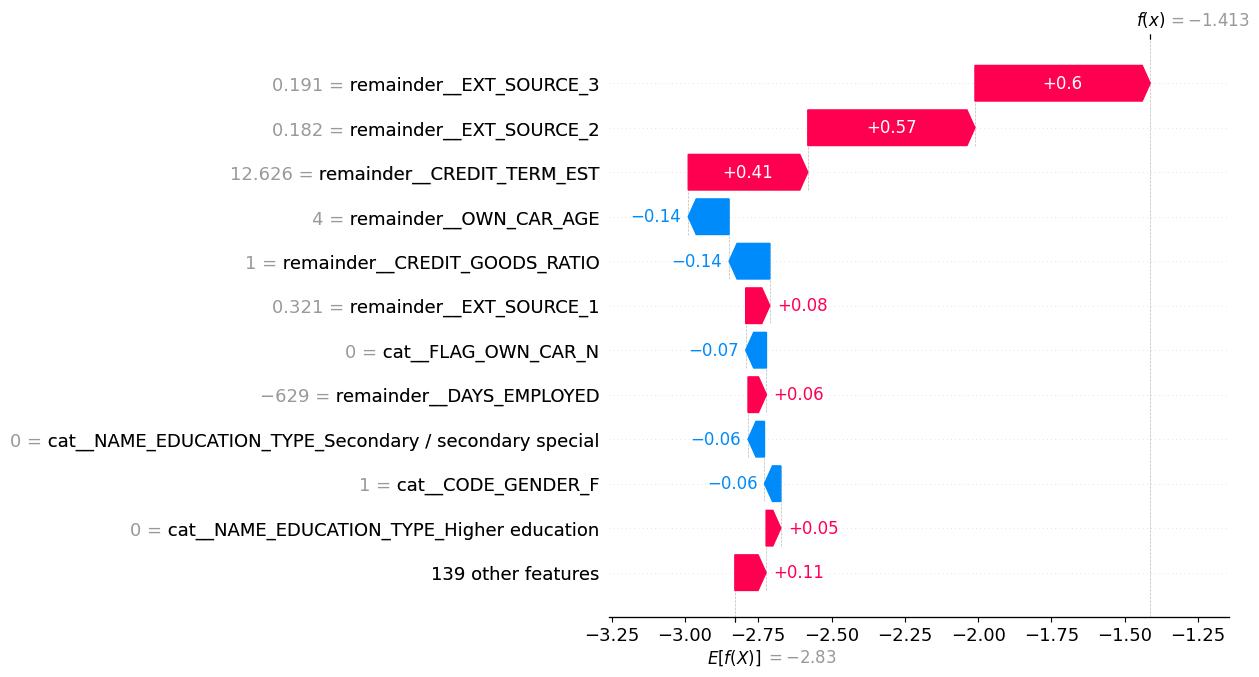

In [ ]:
#Primero el caso concordante TARGET=1, que probablemente sea el ejemplo más interesante.
idx_caso = int(
    caso_2["idx_sample"]
)

print(
    "Caso concordante TARGET=1 - Modelo Real"
)

shap.plots.waterfall(
    shap_values_real[idx_caso],
    max_display=12
)

Caso concordante TARGET=1 - Modelo Synthetic


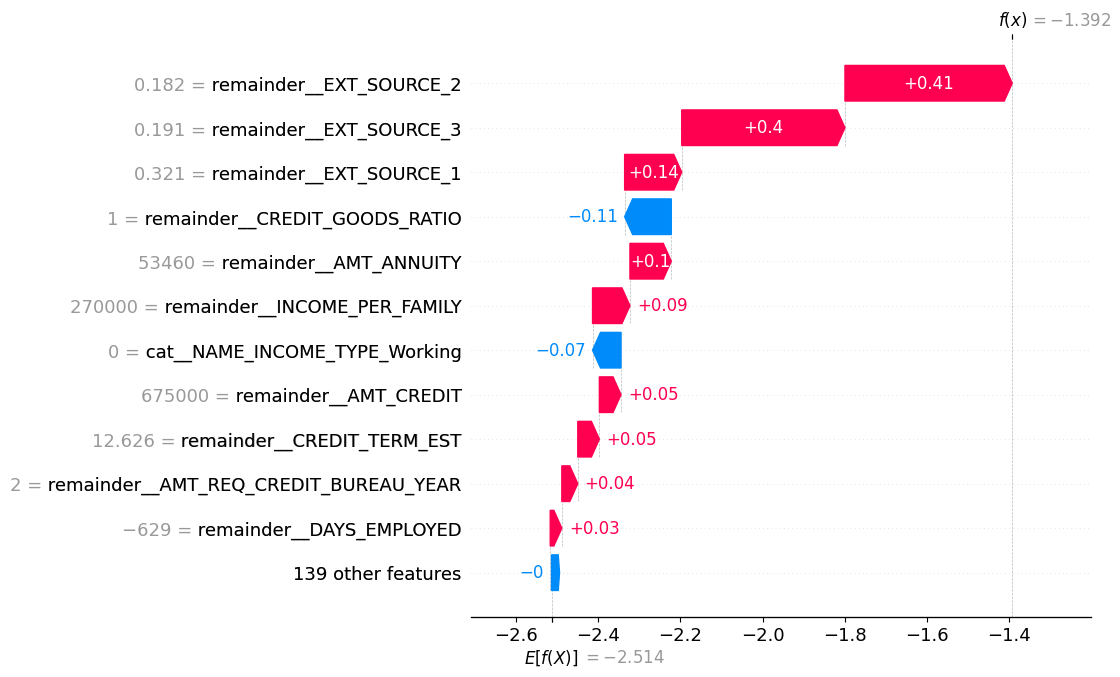

In [ ]:
print(
    "Caso concordante TARGET=1 - Modelo Synthetic"
)

shap.plots.waterfall(
    shap_values_synth[idx_caso],
    max_display=12
)

Los casos locales que acabas de obtener valen la pena conservar porque muestran algo muy útil: incluso cuando las probabilidades son similares, la jerarquía de factores puede cambiar; y cuando las probabilidades divergen, siguen apareciendo variables núcleo comunes como EXT_SOURCE_1/2/3, pero con magnitudes distintas. Eso encaja muy bien con la conclusión de consistencia parcial.

#### 8.10 Síntesis de consistencia explicativa

integramos las tres dimensiones XAI que hemos medido.

| Dimensión                                  |    Resultado |
| ------------------------------------------ | -----------: |
| Spearman importancia global                | **0.688709** |
| Coincidencia Top-5                         |      **60%** |
| Coincidencia Top-10                        |      **60%** |
| Coincidencia Top-20                        |      **70%** |
| Conservación direccional Top-20            |      **95%** |
| Conservación direccional relevante         |   **93.75%** |
| Correlación mediana SHAP individual Top-20 | **0.591803** |


Eso es una historia bastante coherente:

se conserva mejor la dirección de los efectos que la magnitud exacta o la contribución individual de todas las variables.

Y eso me parece una de las conclusiones más interesantes del TFM.

No mezclaría estos números en un score único. Son métricas de naturaleza distinta.


##### 8.10.1 Tabla resumen

In [ ]:
resumen_xai = pd.DataFrame({
    "Dimensión": [
        "Correlación global de importancias",
        "Coincidencia Top-5",
        "Coincidencia Top-10",
        "Coincidencia Top-20",
        "Conservación direccional Top-20",
        "Conservación direccional relevante",
        "Correlación mediana SHAP individual Top-20"
    ],
    "Resultado": [
        0.688709,
        0.60,
        0.60,
        0.70,
        0.95,
        0.9375,
        0.591803
    ]
})

resumen_xai

,Dimensión,Resultado
0,Correlación global de importancias,0.688709
1,Coincidencia Top-5,0.600000
2,Coincidencia Top-10,0.600000
3,Coincidencia Top-20,0.700000
4,Conservación direccional Top-20,0.950000
5,Conservación direccional relevante,0.937500
6,Correlación mediana SHAP individual Top-20,0.591803


##### 8.10.2 Conclusión integrada

La evaluación mediante SHAP muestra que el modelo entrenado con datos sintéticos presenta una consistencia explicativa parcial respecto al modelo de referencia entrenado con datos reales.

A nivel global, la correlación de Spearman entre las importancias SHAP fue de 0.688709, indicando una asociación positiva considerable entre las jerarquías explicativas de ambos modelos. La coincidencia de variables relevantes fue del 60 % en los Top-5 y Top-10 y del 70 % en el Top-20.

La conservación de la dirección de los efectos fue considerablemente mayor. Entre las veinte variables más importantes del modelo Real, el 95 % mantuvo el mismo signo en la relación entre valor de la variable y contribución SHAP. Al restringir el análisis a aquellas variables con relaciones de magnitud relevante en ambos modelos, la coincidencia direccional fue del 93.75 %.

A nivel individual, la consistencia fue más heterogénea. La correlación mediana entre las contribuciones SHAP de ambos modelos para las veinte variables principales fue de 0.591803. Algunas variables, como EXT_SOURCE_2 y EXT_SOURCE_3, mostraron una correspondencia muy elevada entre modelos, mientras que otras presentaron diferencias sustanciales.

Estos resultados indican que el modelo Synthetic conserva en gran medida la dirección de los principales factores de riesgo y parte de la jerarquía global de variables, pero no reproduce de forma completa la magnitud ni el patrón individual de todas las contribuciones.

En consecuencia, la similitud explicativa debe entenderse como parcial y multidimensional. Los datos sintéticos permiten preservar elementos relevantes de la lógica predictiva del modelo, aunque introducen modificaciones en determinadas relaciones que deben ser consideradas al interpretar modelos desarrollados exclusivamente con información sintética.

#### 8.11 Conclusiones de Notebook 08

En este notebook se evaluó la consistencia explicativa entre los modelos LightGBM entrenados con datos reales y sintéticos mediante SHAP.

La comparación global mostró que ambos modelos comparten un núcleo relevante de variables explicativas, especialmente EXT_SOURCE_1, EXT_SOURCE_2 y EXT_SOURCE_3. La correlación de Spearman entre las importancias globales alcanzó 0.688709 y el 70 % de las veinte variables más importantes fueron compartidas por ambos modelos.

Sin embargo, se observaron diferencias relevantes en la magnitud y jerarquía de determinadas variables. Variables como CREDIT_TERM_EST, NAME_EDUCATION_TYPE_Higher education y AMT_GOODS_PRICE presentan reducciones considerables de importancia en el modelo Synthetic, mientras que otras, como HAS_CAR_AGE, adquieren una relevancia superior respecto al modelo Real.

El análisis de dirección mostró una mayor consistencia. El 95 % de las veinte variables principales mantuvieron el mismo signo de efecto y, entre aquellas con relaciones relevantes en ambos modelos, la coincidencia direccional alcanzó el 93.75 %.

A nivel individual, la consistencia fue moderada y heterogénea. La correlación mediana entre contribuciones SHAP de las veinte variables principales fue de 0.591803. EXT_SOURCE_2 y EXT_SOURCE_3 presentaron niveles de correspondencia especialmente elevados, mientras que otras variables mostraron diferencias importantes.

En conjunto, los resultados muestran que el modelo entrenado con datos sintéticos no reproduce exactamente la estructura explicativa del modelo entrenado con datos reales, pero conserva una parte significativa de sus patrones principales. La conservación es especialmente elevada en la dirección de los efectos de las variables más relevantes, mientras que la magnitud y las contribuciones individuales presentan una mayor variabilidad.

Estos resultados complementan la evaluación estadística y predictiva realizada en etapas anteriores y permiten concluir que Gaussian Copula V2.1 preserva parcialmente no solo la utilidad predictiva, sino también determinados patrones explicativos relevantes para la estimación de la Probabilidad de Default.